# CCLE extra benchmark plots and EDA

This notebook adds plots beyond `plot_within_dataset_figures.ipynb`. It uses the CCLE within-dataset benchmark outputs, optional older baseline outputs, and raw CSA response/feature files when available.

Generated images are saved under `extra_figures/` next to this notebook.


In [1]:
from pathlib import Path
import os
import json
import math

import numpy as np
import pandas as pd

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("XDG_CACHE_HOME", str(Path.cwd() / ".cache"))
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.frameon": False,
})

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "within_dataset_4models_results.csv").exists():
    NOTEBOOK_DIR = Path("new_notebook/results/results_ccle").resolve()

REPO_ROOT = NOTEBOOK_DIR
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "data").exists():
    REPO_ROOT = REPO_ROOT.parent

RESULT_DIR = NOTEBOOK_DIR
FIG_DIR = RESULT_DIR / "extra_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RAW_DIR = REPO_ROOT / "data/csa_data/raw_data"
X_DIR = RAW_DIR / "x_data"
SPLIT_DIR = RAW_DIR / "splits"
BASELINE_CANDIDATES = [
    REPO_ROOT / "models/five_dataset_4models_results/CCLE/results.csv",
    REPO_ROOT / "models/five_dataset_4models_results_cold_cell/CCLE/results.csv",
]

RESULTS_CSV = RESULT_DIR / "within_dataset_4models_results.csv"
SUMMARY_CSV = RESULT_DIR / "within_dataset_4models_summary.csv"
CONTRACT_JSON = RESULT_DIR / "benchmark_contract.json"

results = pd.read_csv(RESULTS_CSV)
summary = pd.read_csv(SUMMARY_CSV).sort_values("r2_mean", ascending=False)
contract = json.loads(CONTRACT_JSON.read_text(encoding="utf-8")) if CONTRACT_JSON.exists() else {}
model_order = summary["model"].tolist()
metric_specs = {
    "r2": {"label": "$R^2$", "higher_better": True},
    "rmse": {"label": "RMSE", "higher_better": False},
    "mae": {"label": "MAE", "higher_better": False},
    "pearson": {"label": "Pearson r", "higher_better": True},
}

baseline_path = next((p for p in BASELINE_CANDIDATES if p.exists()), None)
baseline = pd.read_csv(baseline_path) if baseline_path else pd.DataFrame()

print("Result dir:", RESULT_DIR)
print("Raw data dir:", RAW_DIR if RAW_DIR.exists() else "missing")
print("Rows in benchmark results:", len(results))
print("Models:", model_order)
print("Optional baseline:", baseline_path if baseline_path else "not found")
display(summary)




Matplotlib is building the font cache; this may take a moment.


Result dir: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/results/results_ccle
Raw data dir: /Users/vietanh/Desktop/ML-Predicting-drug-response/data/csa_data/raw_data
Rows in benchmark results: 45
Models: ['lightgbm', 'graphdrp', 'simple_linear_nn', 'random_forest', 'ridge']
Optional baseline: /Users/vietanh/Desktop/ML-Predicting-drug-response/models/five_dataset_4models_results/CCLE/results.csv


,dataset,model,folds,n_test_mean,r2_mean,r2_std,rmse_mean,rmse_std,mae_mean,mae_std,pearson_mean,pearson_std,train_seconds_mean
0,CCLE,lightgbm,3,951.666667,0.809760,0.001732,0.070798,0.001957,0.055032,0.001169,0.900068,0.000773,35.972126
1,CCLE,graphdrp,3,951.666667,0.773596,0.006012,0.077234,0.002537,0.059858,0.001850,0.886164,0.001575,940.948430
2,CCLE,simple_linear_nn,3,951.666667,0.771546,0.007381,0.077556,0.001140,0.060600,0.000999,0.879727,0.003102,140.227024
3,CCLE,random_forest,3,951.666667,0.745973,0.013312,0.081815,0.003894,0.062858,0.002739,0.863828,0.007751,607.310138
4,CCLE,ridge,3,951.666667,0.745086,0.006962,0.081946,0.002376,0.062692,0.002547,0.863599,0.004129,1.395319


## Benchmark diagnostics

These views use the per-fold/per-stage benchmark rows.


In [2]:
def savefig(name):
    path = FIG_DIR / name
    plt.savefig(path, bbox_inches="tight")
    print(f"Saved: {path}")

ok = results[results["status"].eq("ok")].copy()
test_ok = ok[ok["stage"].eq("test")].copy()

def ordered_model_series(s):
    return pd.Categorical(s, categories=model_order, ordered=True)




Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/results/results_ccle/extra_figures/fig12_overfit_generalization_gap.png


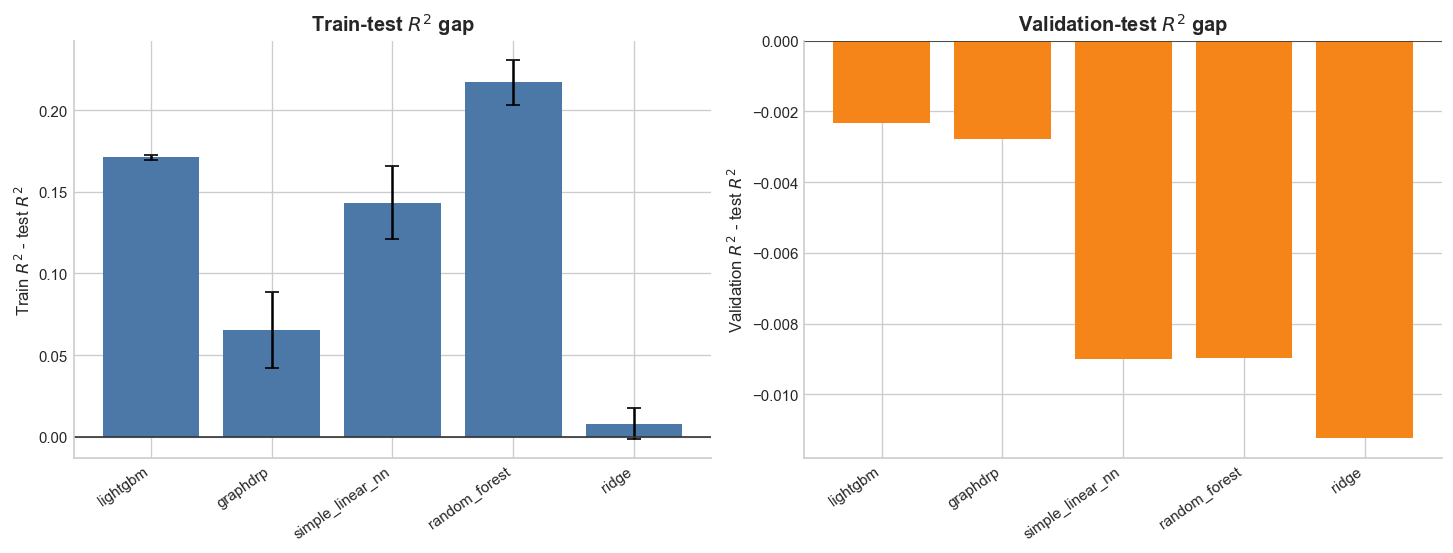

,model,r2_train_minus_test,r2_train_minus_test_std,r2_val_minus_test,rmse_test_minus_train
0,lightgbm,0.171101,0.001389,-0.002336,0.048490
1,graphdrp,0.065424,0.023438,-0.002782,0.012623
2,simple_linear_nn,0.143293,0.022399,-0.008999,0.030644
3,random_forest,0.216961,0.013878,-0.008971,0.050770
4,ridge,0.007981,0.009580,-0.011246,0.001814


In [3]:
# Fig 12: overfit / generalization gap by model and fold.
wide = ok.pivot_table(index=["dataset", "fold", "model"], columns="stage", values=["r2", "rmse", "mae", "pearson"])
wide.columns = [f"{metric}_{stage}" for metric, stage in wide.columns]
wide = wide.reset_index()
wide["model"] = ordered_model_series(wide["model"])
wide["r2_train_minus_test"] = wide["r2_train"] - wide["r2_test"]
wide["r2_val_minus_test"] = wide["r2_val"] - wide["r2_test"]
wide["rmse_test_minus_train"] = wide["rmse_test"] - wide["rmse_train"]

gap = (
    wide.groupby("model", observed=False)
    .agg(
        r2_train_minus_test=("r2_train_minus_test", "mean"),
        r2_train_minus_test_std=("r2_train_minus_test", "std"),
        r2_val_minus_test=("r2_val_minus_test", "mean"),
        rmse_test_minus_train=("rmse_test_minus_train", "mean"),
    )
    .reset_index()
    .sort_values("model")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
x = np.arange(len(gap))
axes[0].bar(x, gap["r2_train_minus_test"], yerr=gap["r2_train_minus_test_std"], capsize=4, color="#4c78a8")
axes[0].axhline(0, color="#333333", linewidth=1)
axes[0].set_title("Train-test $R^2$ gap")
axes[0].set_ylabel("Train $R^2$ - test $R^2$")
axes[1].bar(x, gap["r2_val_minus_test"], color="#f58518")
axes[1].axhline(0, color="#333333", linewidth=1)
axes[1].set_title("Validation-test $R^2$ gap")
axes[1].set_ylabel("Validation $R^2$ - test $R^2$")
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(gap["model"], rotation=35, ha="right")
savefig("fig12_overfit_generalization_gap.png")
plt.show()
display(gap)




Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/results/results_ccle/extra_figures/fig13_fold_model_r2_heatmap.png


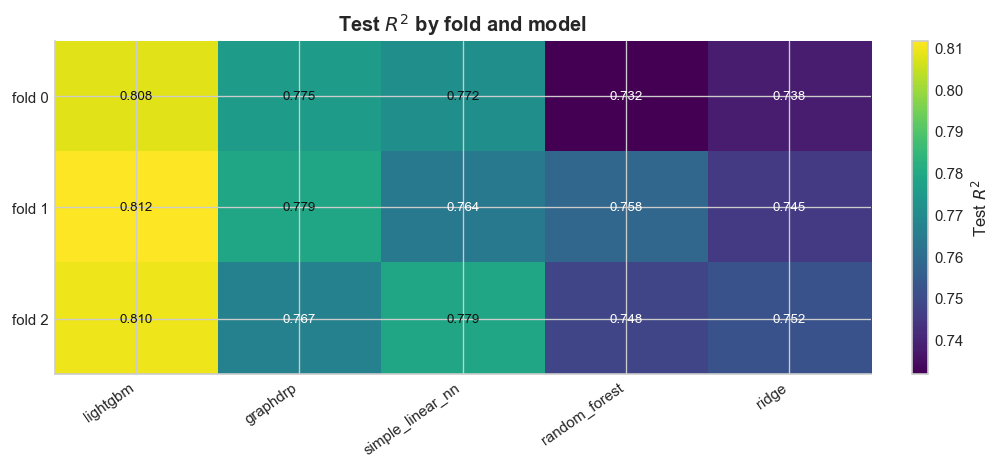

In [4]:
# Fig 13: fold x model heatmap for test R2.
heat = test_ok.pivot_table(index="fold", columns="model", values="r2").reindex(columns=model_order)
fig, ax = plt.subplots(figsize=(1.25 * len(model_order) + 2, 3.8), constrained_layout=True)
im = ax.imshow(heat.to_numpy(), aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=35, ha="right")
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels([f"fold {i}" for i in heat.index])
ax.set_title("Test $R^2$ by fold and model")
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        value = heat.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.3f}", ha="center", va="center", color="white" if value < np.nanmean(heat.to_numpy()) else "#111111", fontsize=8)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Test $R^2$")
savefig("fig13_fold_model_r2_heatmap.png")
plt.show()




Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/results/results_ccle/extra_figures/fig14_normalized_model_profile.png


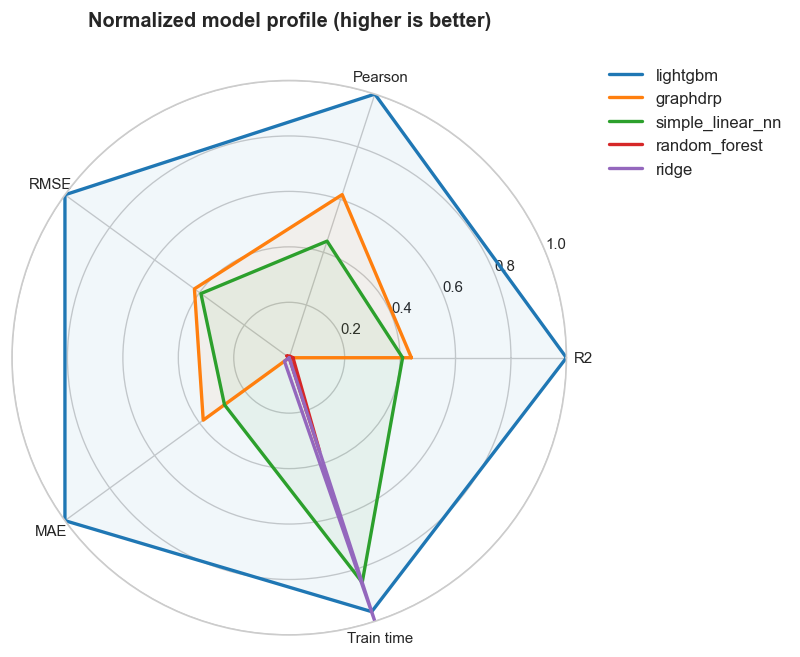

,model,r2,pearson,rmse,mae,train_seconds
0,lightgbm,1.000000,1.000000,1.000000,1.000000,0.963199
1,graphdrp,0.440827,0.618742,0.422604,0.383345,0.000000
2,simple_linear_nn,0.409136,0.442239,0.393746,0.288609,0.852236
3,random_forest,0.013723,0.006278,0.011703,0.000000,0.355103
4,ridge,0.000000,0.000000,0.000000,0.021214,1.000000


In [5]:
# Fig 14: normalized model profile across metrics.
profile = summary.set_index("model").loc[model_order].reset_index().copy()
metrics = ["r2", "pearson", "rmse", "mae", "train_seconds"]
labels = ["R2", "Pearson", "RMSE", "MAE", "Train time"]
score = pd.DataFrame({"model": profile["model"]})
for metric in metrics:
    col = f"{metric}_mean" if metric != "train_seconds" else "train_seconds_mean"
    values = profile[col].astype(float)
    lo, hi = values.min(), values.max()
    norm = (values - lo) / (hi - lo) if hi > lo else values * 0 + 0.5
    if metric in ["rmse", "mae", "train_seconds"]:
        norm = 1 - norm
    score[metric] = norm

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]
fig = plt.figure(figsize=(7, 6))
ax = plt.subplot(111, polar=True)
for _, row in score.iterrows():
    values = [row[m] for m in metrics] + [row[metrics[0]]]
    ax.plot(angles, values, linewidth=2, label=row["model"])
    ax.fill(angles, values, alpha=0.06)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title("Normalized model profile (higher is better)", y=1.08)
ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.05))
savefig("fig14_normalized_model_profile.png")
plt.show()
display(score)




Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/results/results_ccle/extra_figures/fig15_benchmark_vs_older_baselines.png


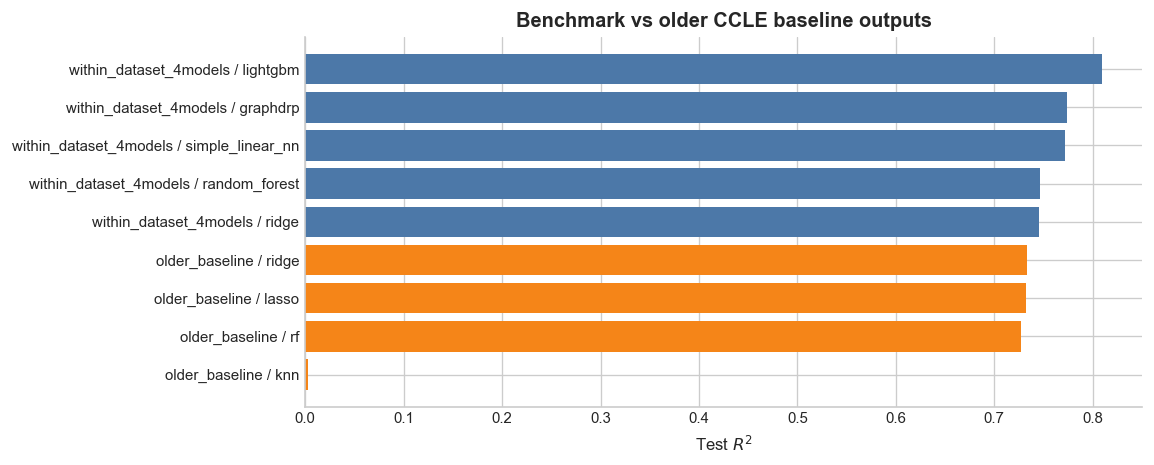

,model,test_r2,test_rmse,test_pearson,fit_seconds,source,label
0,lightgbm,0.809760,0.070798,0.900068,35.972126,within_dataset_4models,within_dataset_4models / lightgbm
1,graphdrp,0.773596,0.077234,0.886164,940.948430,within_dataset_4models,within_dataset_4models / graphdrp
2,simple_linear_nn,0.771546,0.077556,0.879727,140.227024,within_dataset_4models,within_dataset_4models / simple_linear_nn
3,random_forest,0.745973,0.081815,0.863828,607.310138,within_dataset_4models,within_dataset_4models / random_forest
4,ridge,0.745086,0.081946,0.863599,1.395319,within_dataset_4models,within_dataset_4models / ridge
6,ridge,0.733454,0.085189,0.856521,0.040168,older_baseline,older_baseline / ridge
5,lasso,0.732401,0.085357,0.856854,0.143013,older_baseline,older_baseline / lasso
7,rf,0.726717,0.086259,0.853488,1.771188,older_baseline,older_baseline / rf
8,knn,0.002526,0.164797,0.148028,0.000916,older_baseline,older_baseline / knn


In [6]:
# Fig 15: optional comparison with older baseline output.
if baseline.empty:
    print("No older baseline results.csv found; skipping baseline comparison.")
else:
    bench = summary[["model", "r2_mean", "rmse_mean", "pearson_mean", "train_seconds_mean"]].copy()
    bench["source"] = "within_dataset_4models"
    bench = bench.rename(columns={"r2_mean": "test_r2", "rmse_mean": "test_rmse", "pearson_mean": "test_pearson", "train_seconds_mean": "fit_seconds"})
    old = baseline[["model", "test_r2", "test_rmse", "test_pearson", "fit_seconds"]].copy()
    old["source"] = "older_baseline"
    comp = pd.concat([bench, old], ignore_index=True)
    comp["label"] = comp["source"] + " / " + comp["model"]
    comp = comp.sort_values("test_r2", ascending=False)

    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(comp))))
    colors = comp["source"].map({"within_dataset_4models": "#4c78a8", "older_baseline": "#f58518"}).fillna("#8a8f98")
    ax.barh(np.arange(len(comp)), comp["test_r2"], color=colors)
    ax.set_yticks(np.arange(len(comp)))
    ax.set_yticklabels(comp["label"])
    ax.invert_yaxis()
    ax.set_xlabel("Test $R^2$")
    ax.set_title("Benchmark vs older CCLE baseline outputs")
    savefig("fig15_benchmark_vs_older_baselines.png")
    plt.show()
    display(comp)




## Response-table EDA

These views use `train_y_data.csv`, `val_y_data.csv`, `test_y_data.csv`, and the full `y_data/response.tsv` when available.


In [7]:
split_frames = []
for split_name in ["train", "val", "test"]:
    path = RAW_DIR / f"{split_name}_y_data.csv"
    if path.exists():
        df = pd.read_csv(path)
        df["split"] = split_name
        split_frames.append(df)
response_splits = pd.concat(split_frames, ignore_index=True) if split_frames else pd.DataFrame()

response_path = RAW_DIR / "y_data/response.tsv"
response_all = pd.read_csv(response_path, sep="\t", low_memory=False) if response_path.exists() else response_splits.copy()
response_ccle = response_all[response_all["source"].eq("CCLE")].copy() if "source" in response_all else response_all.copy()

print("Split response rows:", len(response_splits))
print("Full CCLE response rows:", len(response_ccle))
print("Unique cell lines:", response_ccle["improve_sample_id"].nunique() if "improve_sample_id" in response_ccle else "n/a")
print("Unique drugs:", response_ccle["improve_chem_id"].nunique() if "improve_chem_id" in response_ccle else "n/a")
display(response_splits.head())




Split response rows: 9519
Full CCLE response rows: 9519
Unique cell lines: 411
Unique drugs: 24


,source,improve_sample_id,improve_chem_id,study,auc,ic50,ec50,ec50se,r2fit,einf,hs,aac1,auc1,dss1,split
0,CCLE,ACH-000956,Drug_749,fake_exp,0.7153,5.660,5.660,0.6867,0.9533,0.0000,0.6669,0.2240,0.7760,0.1661,train
1,CCLE,ACH-000070,Drug_749,fake_exp,0.7692,5.379,5.379,0.8163,0.8768,0.0000,1.2990,0.1146,0.8854,0.0840,train
2,CCLE,ACH-000411,Drug_749,fake_exp,0.8371,NaN,6.524,0.1646,0.8962,0.6129,3.3760,0.1576,0.8424,0.1209,train
3,CCLE,ACH-000649,Drug_749,fake_exp,0.8146,5.110,5.110,1.8160,0.9470,0.0000,1.7990,0.0497,0.9503,0.0299,train
4,CCLE,ACH-001306,Drug_749,fake_exp,0.7727,5.337,5.337,0.8538,0.9352,0.0000,0.9229,0.1316,0.8684,0.0902,train


Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/results/results_ccle/extra_figures/fig16_response_distributions_by_split.png


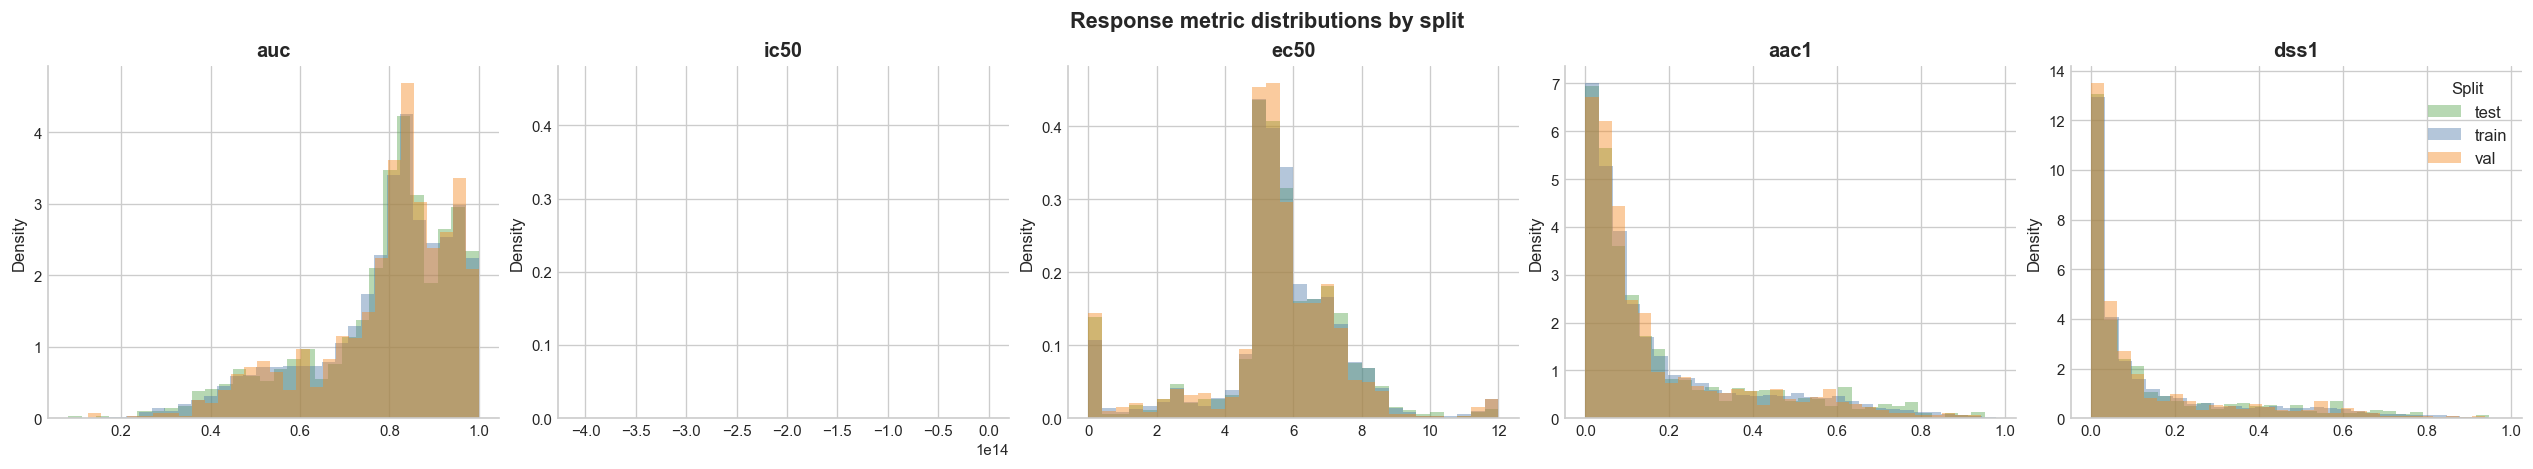

In [8]:
# Fig 16: target distributions by split.
if response_splits.empty:
    print("No split response CSV files found; skipping target distributions.")
else:
    targets = [c for c in ["auc", "ic50", "ec50", "aac1", "dss1"] if c in response_splits.columns]
    fig, axes = plt.subplots(1, len(targets), figsize=(4.2 * len(targets), 3.8), constrained_layout=True)
    if len(targets) == 1:
        axes = [axes]
    colors = {"train": "#4c78a8", "val": "#f58518", "test": "#54a24b"}
    for ax, target in zip(axes, targets):
        for split_name, split_df in response_splits.groupby("split"):
            values = pd.to_numeric(split_df[target], errors="coerce").dropna()
            ax.hist(values, bins=30, alpha=0.42, density=True, label=split_name, color=colors.get(split_name))
        ax.set_title(target)
        ax.set_ylabel("Density")
    axes[-1].legend(title="Split")
    fig.suptitle("Response metric distributions by split", fontsize=13, fontweight="bold")
    savefig("fig16_response_distributions_by_split.png")
    plt.show()




Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/results/results_ccle/extra_figures/fig17_response_missingness.png


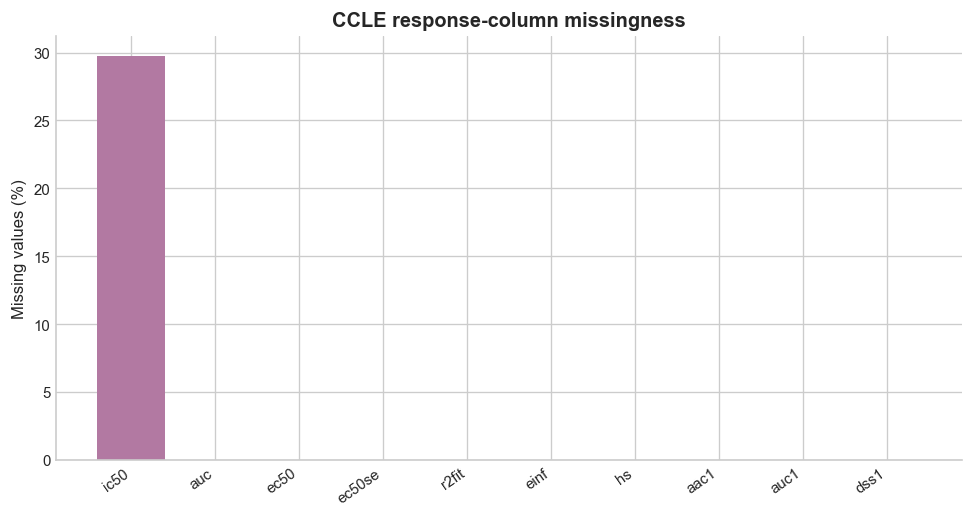

,missing_percent
ic50,29.730014
auc,0.000000
ec50,0.000000
ec50se,0.000000
r2fit,0.000000
einf,0.000000
hs,0.000000
aac1,0.000000
auc1,0.000000
dss1,0.000000


In [9]:
# Fig 17: missingness in response columns.
if response_ccle.empty:
    print("No CCLE response table found; skipping missingness plot.")
else:
    metric_cols = [c for c in ["auc", "ic50", "ec50", "ec50se", "r2fit", "einf", "hs", "aac1", "auc1", "dss1"] if c in response_ccle.columns]
    missing = response_ccle[metric_cols].isna().mean().sort_values(ascending=False) * 100
    fig, ax = plt.subplots(figsize=(8, 4.2), constrained_layout=True)
    x = np.arange(len(missing))
    ax.bar(x, missing.values, color="#b279a2")
    ax.set_xticks(x)
    ax.set_xticklabels(missing.index, rotation=35, ha="right")
    ax.set_ylabel("Missing values (%)")
    ax.set_title("CCLE response-column missingness")
    savefig("fig17_response_missingness.png")
    plt.show()
    display(missing.to_frame("missing_percent"))




Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/results/results_ccle/extra_figures/fig18_response_coverage_top_entities.png


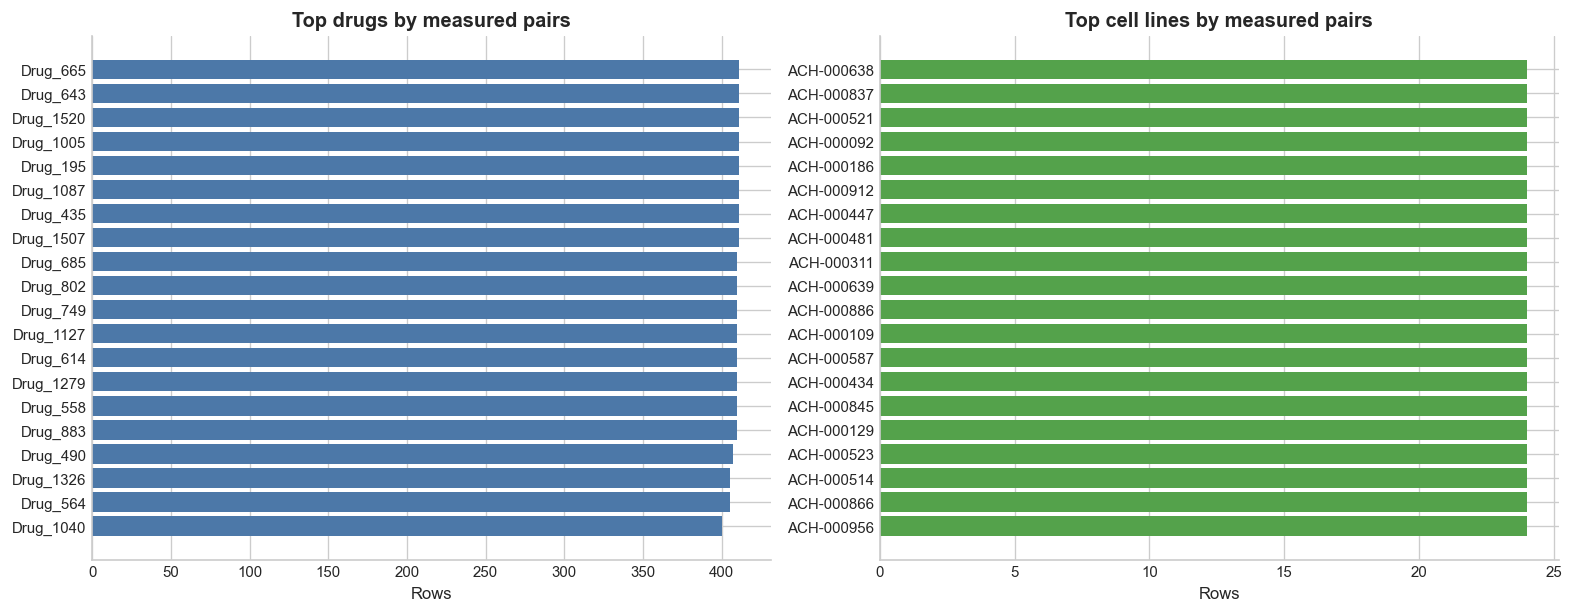

In [10]:
# Fig 18: response coverage by drug and cell line.
if response_ccle.empty:
    print("No CCLE response table found; skipping coverage plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    drug_counts = response_ccle["improve_chem_id"].value_counts().head(20).sort_values()
    cell_counts = response_ccle["improve_sample_id"].value_counts().head(20).sort_values()
    axes[0].barh(drug_counts.index.astype(str), drug_counts.values, color="#4c78a8")
    axes[0].set_title("Top drugs by measured pairs")
    axes[0].set_xlabel("Rows")
    axes[1].barh(cell_counts.index.astype(str), cell_counts.values, color="#54a24b")
    axes[1].set_title("Top cell lines by measured pairs")
    axes[1].set_xlabel("Rows")
    savefig("fig18_response_coverage_top_entities.png")
    plt.show()




Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/results/results_ccle/extra_figures/fig19_drug_auc_heterogeneity.png


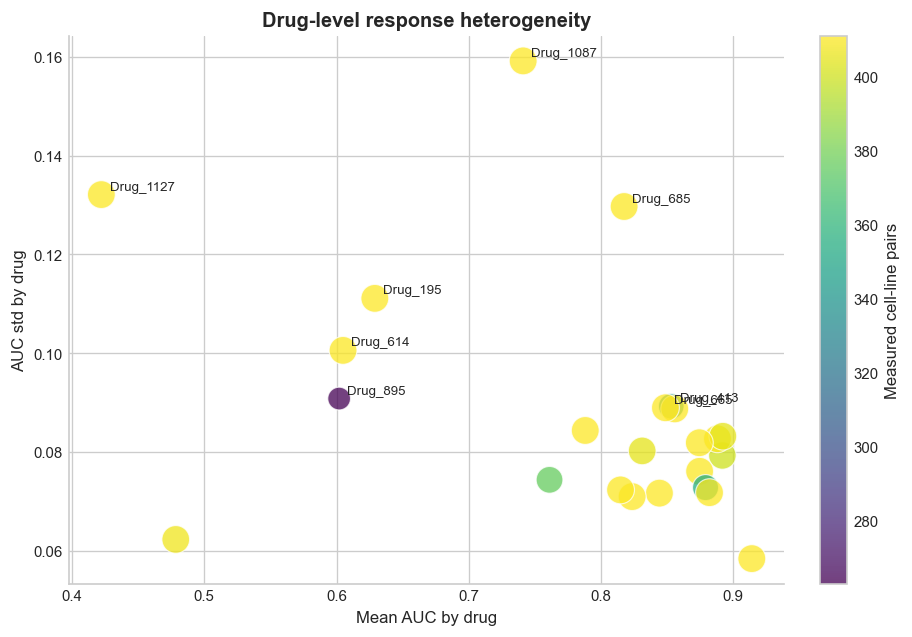

,improve_chem_id,n,auc_mean,auc_std
2,Drug_1087,411,0.741136,0.159192
3,Drug_1127,410,0.422203,0.132110
17,Drug_685,410,0.817462,0.129699
8,Drug_195,411,0.628992,0.111098
14,Drug_614,410,0.604938,0.100560
23,Drug_895,263,0.602010,0.090801
9,Drug_413,341,0.853110,0.089240
16,Drug_665,411,0.848708,0.088940
10,Drug_435,411,0.855758,0.088713
7,Drug_1520,411,0.788083,0.084341


In [11]:
# Fig 19: drug-level AUC heterogeneity.
if response_ccle.empty or "auc" not in response_ccle.columns:
    print("No CCLE AUC column found; skipping drug heterogeneity plot.")
else:
    drug_stats = (
        response_ccle.assign(auc=pd.to_numeric(response_ccle["auc"], errors="coerce"))
        .dropna(subset=["auc"])
        .groupby("improve_chem_id")
        .agg(n=("auc", "size"), auc_mean=("auc", "mean"), auc_std=("auc", "std"))
        .query("n >= 20")
        .reset_index()
    )
    sizes = 20 + 260 * drug_stats["n"] / drug_stats["n"].max()
    fig, ax = plt.subplots(figsize=(7.5, 5.2), constrained_layout=True)
    scatter = ax.scatter(drug_stats["auc_mean"], drug_stats["auc_std"], s=sizes, c=drug_stats["n"], cmap="viridis", alpha=0.75, edgecolor="white", linewidth=0.7)
    ax.set_xlabel("Mean AUC by drug")
    ax.set_ylabel("AUC std by drug")
    ax.set_title("Drug-level response heterogeneity")
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Measured cell-line pairs")
    for _, row in drug_stats.nlargest(8, "auc_std").iterrows():
        ax.annotate(row["improve_chem_id"], (row["auc_mean"], row["auc_std"]), xytext=(5, 3), textcoords="offset points", fontsize=8)
    savefig("fig19_drug_auc_heterogeneity.png")
    plt.show()
    display(drug_stats.sort_values("auc_std", ascending=False).head(15))




## Split and feature context

These plots summarize the official split files and the available feature modalities.


Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/results/results_ccle/extra_figures/fig20_official_split_sizes.png


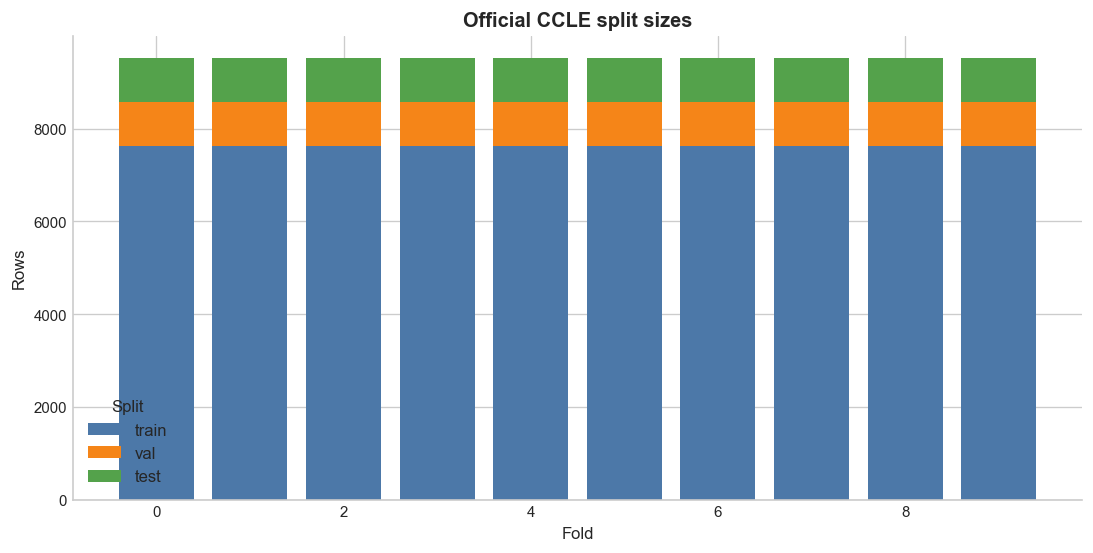

split,train,val,test
fold,,,
0,7616,952,951
1,7616,951,952
2,7615,952,952
3,7615,952,952
4,7615,952,952
5,7615,952,952
6,7615,952,952
7,7615,952,952
8,7615,952,952


In [12]:
# Fig 20: official CCLE split sizes across folds.
split_rows = []
for fold in range(10):
    for split_name in ["train", "val", "test"]:
        path = SPLIT_DIR / f"CCLE_split_{fold}_{split_name}.txt"
        if path.exists():
            with path.open("r", encoding="utf-8") as fh:
                n = sum(1 for line in fh if line.strip() != "")
            split_rows.append({"fold": fold, "split": split_name, "rows": n})
split_sizes = pd.DataFrame(split_rows)

if split_sizes.empty:
    print("No CCLE split files found; skipping split-size plot.")
else:
    pivot = split_sizes.pivot(index="fold", columns="split", values="rows").reindex(columns=["train", "val", "test"])
    fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
    bottom = np.zeros(len(pivot))
    colors = {"train": "#4c78a8", "val": "#f58518", "test": "#54a24b"}
    for split_name in pivot.columns:
        ax.bar(pivot.index, pivot[split_name], bottom=bottom, label=split_name, color=colors.get(split_name))
        bottom += pivot[split_name].fillna(0).to_numpy()
    ax.set_xlabel("Fold")
    ax.set_ylabel("Rows")
    ax.set_title("Official CCLE split sizes")
    ax.legend(title="Split")
    savefig("fig20_official_split_sizes.png")
    plt.show()
    display(pivot)




Saved: /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/results/results_ccle/extra_figures/fig21_feature_modality_context.png


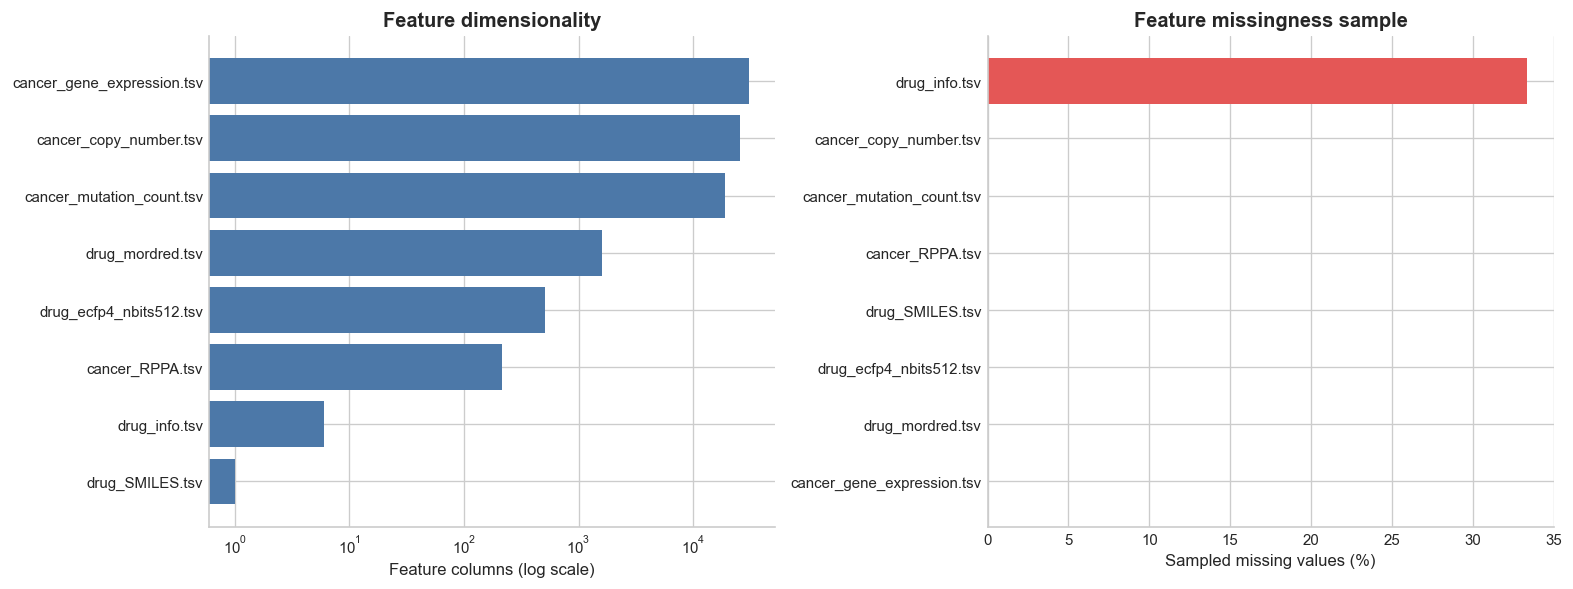

,file,rows,feature_cols,sample_missing_pct
0,cancer_gene_expression.tsv,1009,30805,0.000000
6,cancer_copy_number.tsv,1020,25331,0.002274
7,cancer_mutation_count.tsv,1026,18739,0.001430
1,drug_mordred.tsv,1565,1613,0.000000
2,drug_ecfp4_nbits512.tsv,1565,512,0.000000
5,cancer_RPPA.tsv,789,214,0.000000
4,drug_info.tsv,2145,6,33.333333
3,drug_SMILES.tsv,1565,1,0.000000


In [13]:
# Fig 21: feature modality dimensions and sampled missingness.
def count_lines(path):
    if not path.exists():
        return np.nan
    with path.open("r", encoding="utf-8", errors="ignore") as fh:
        return max(sum(1 for _ in fh) - 1, 0)

def feature_profile(path, sep="\t", id_cols=1, sample_rows=250):
    if not path.exists():
        return None
    header = pd.read_csv(path, sep=sep, nrows=0)
    sample = pd.read_csv(path, sep=sep, nrows=sample_rows, dtype=str)
    feature_cols = max(len(header.columns) - id_cols, 0)
    missing_pct = sample.iloc[:, id_cols:].isna().mean().mean() * 100 if feature_cols else 0.0
    return {
        "file": path.name,
        "rows": count_lines(path),
        "feature_cols": feature_cols,
        "sample_missing_pct": missing_pct,
    }

profiles = []
for fname, id_cols in [
    ("cancer_gene_expression.tsv", 1),
    ("drug_mordred.tsv", 1),
    ("drug_ecfp4_nbits512.tsv", 1),
    ("drug_SMILES.tsv", 1),
    ("drug_info.tsv", 1),
    ("cancer_RPPA.tsv", 1),
    ("cancer_copy_number.tsv", 1),
    ("cancer_mutation_count.tsv", 1),
]:
    item = feature_profile(X_DIR / fname, id_cols=id_cols)
    if item:
        profiles.append(item)
feature_profiles = pd.DataFrame(profiles)

if feature_profiles.empty:
    print("No feature files found; skipping feature profile plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
    ordered = feature_profiles.sort_values("feature_cols", ascending=True)
    axes[0].barh(ordered["file"], ordered["feature_cols"], color="#4c78a8")
    axes[0].set_xscale("log")
    axes[0].set_xlabel("Feature columns (log scale)")
    axes[0].set_title("Feature dimensionality")
    miss = feature_profiles.sort_values("sample_missing_pct", ascending=True)
    axes[1].barh(miss["file"], miss["sample_missing_pct"], color="#e45756")
    axes[1].set_xlabel("Sampled missing values (%)")
    axes[1].set_title("Feature missingness sample")
    savefig("fig21_feature_modality_context.png")
    plt.show()
    display(feature_profiles.sort_values("feature_cols", ascending=False))




## Quick takeaways helper

Run the final cell after generating the figures to print a compact checklist of what was created.


In [14]:
created = sorted(p.name for p in FIG_DIR.glob("*.png"))
print(f"Created {len(created)} extra figure(s) in {FIG_DIR}")
for name in created:
    print("-", name)




Created 10 extra figure(s) in /Users/vietanh/Desktop/ML-Predicting-drug-response/new_notebook/results/results_ccle/extra_figures
- fig12_overfit_generalization_gap.png
- fig13_fold_model_r2_heatmap.png
- fig14_normalized_model_profile.png
- fig15_benchmark_vs_older_baselines.png
- fig16_response_distributions_by_split.png
- fig17_response_missingness.png
- fig18_response_coverage_top_entities.png
- fig19_drug_auc_heterogeneity.png
- fig20_official_split_sizes.png
- fig21_feature_modality_context.png
